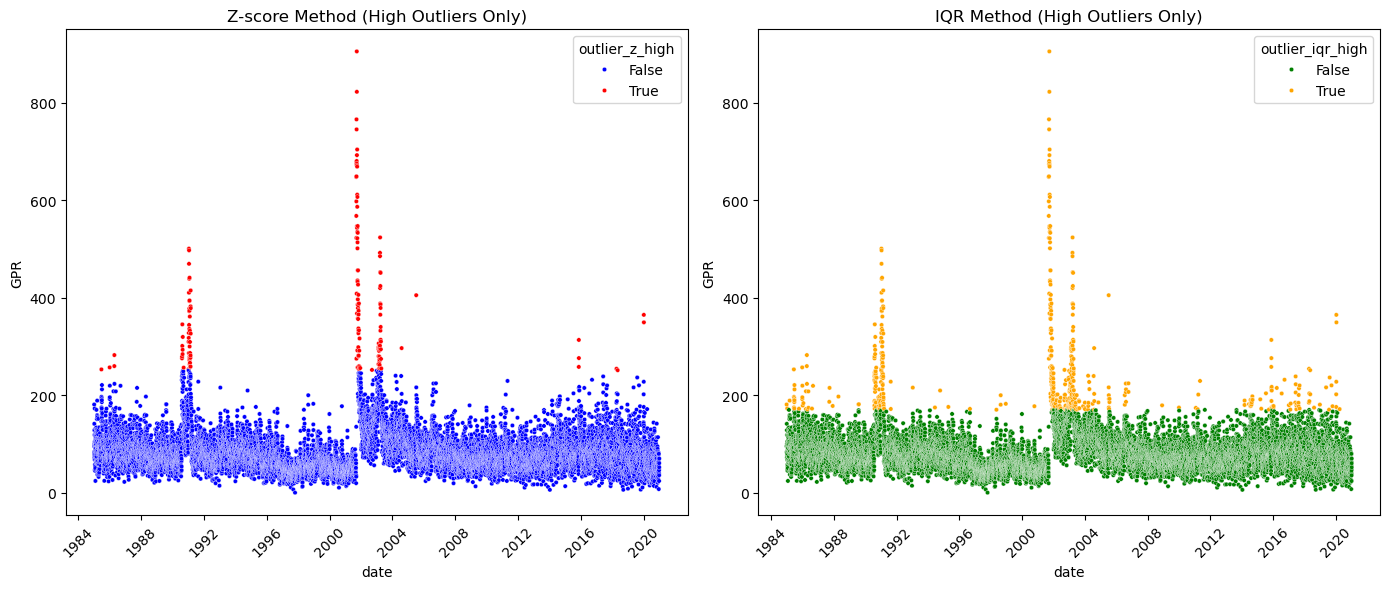

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# 1. 读取数据
file_path = "./Data/data_gpr_daily_recent.xlsx"  # 替换为实际路径
df = pd.read_excel(file_path)

# 2. 计算 log(GPR)
df['log_GPR'] = np.log1p(df['GPR'])  # 避免 log(0)

# 3. Z-score 方法（基于 log(GPR)）
df['z_log_GPR'] = zscore(df['log_GPR'])
df['outlier_z_high'] = df['z_log_GPR'] > 2.5  # 只保留高异常值

# 4. IQR 方法（基于原始 GPR）
Q1 = df['GPR'].quantile(0.25)
Q3 = df['GPR'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df['outlier_iqr_high'] = df['GPR'] > upper_bound  # 只保留高异常值

# 5. 可视化：仅高异常
plt.figure(figsize=(14, 6))

# 左图：Z-score 异常
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df,
    x='date', y='GPR',
    hue='outlier_z_high',
    palette={True: 'red', False: 'blue'},
    s=10
)
plt.title("Z-score Method (High Outliers Only)")
plt.xticks(rotation=45)

# 右图：IQR 异常
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df,
    x='date', y='GPR',
    hue='outlier_iqr_high',
    palette={True: 'orange', False: 'green'},
    s=10
)
plt.title("IQR Method (High Outliers Only)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
df[df['GPR']>upper_bound].set_index('date').to_excel('./Data/target_gpr_date.xlsx', index='date')

In [3]:
# 1. 读取数据
file_path = "./Data/data_gpr_daily_recent.xlsx"  # 替换为实际路径
df = pd.read_excel(file_path)


<Axes: title={'center': 'GPR Over Time'}, xlabel='date'>

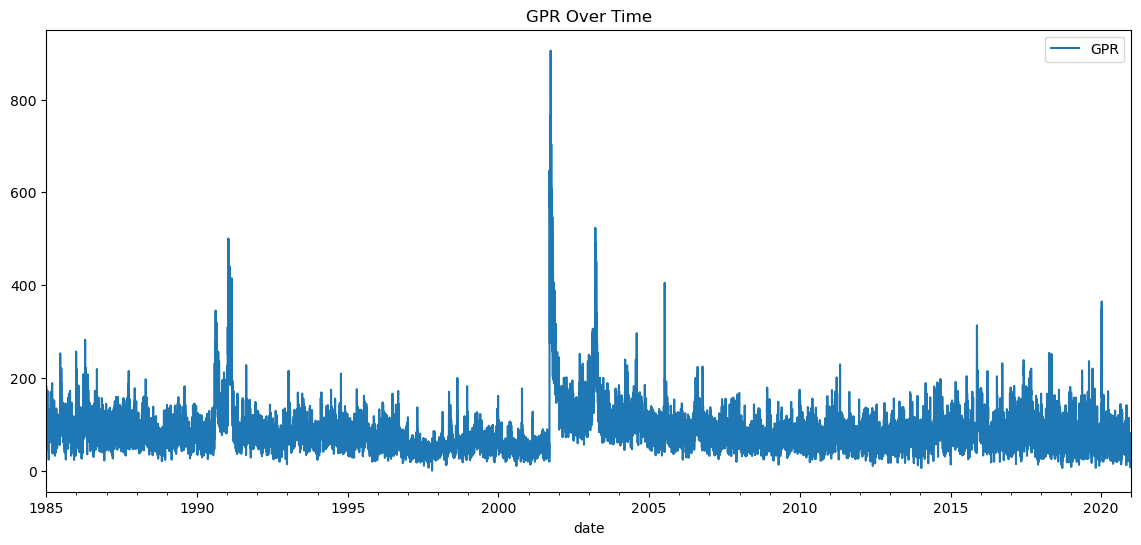

In [3]:
df.plot(x='date', y='GPR', kind='line', figsize=(14, 6), title='GPR Over Time')

In [ ]:
df